# 02 — Análisis Exploratorio de Datos (EDA)

En este notebook se realiza un análisis exploratorio de los datos históricos
de Bitcoin (BTC-USD) obtenidos durante la etapa de adquisición.

El objetivo es estudiar las propiedades estadísticas de los retornos diarios
antes de desarrollar una estrategia cuantitativa.

Se analizarán:

- Retornos diarios
- Tendencia central
- Volatilidad
- Distribución de retornos
- Valores extremos
- Asimetría (Skewness)
- Curtosis (Kurtosis)
- Medias móviles

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Carga de datos

In [4]:
btc = pd.read_csv(
    "./../data/raw/btc_usd.csv",
    index_col="Date",
    parse_dates=True
)

## 2. Cálculo de retornos diarios

In [6]:
# Retorno diario porcentual
btc["daily_return"] = btc["Close"].pct_change()

btc[["Close", "daily_return"]].head()

,Close,daily_return
Date,,
2018-01-01,13657.200195,NaN
2018-01-02,14982.099609,0.097011
2018-01-03,15201.000000,0.014611
2018-01-04,15599.200195,0.026196
2018-01-05,17429.500000,0.117333


daily_return responde a esta pregunta:

$$ R_t = \frac{P_t-P_{t-1}}{P_{t-1}} $$

Por ejemplo, si Bitcoin pasa de USD 100 a USD 105:

$$ R = \frac{105-100}{100}=0.05=5\% $$

Ahora observemos estadísticamente esos retornos:

## 3. Estadísticas descriptivas

In [9]:
btc["daily_return"].describe()

count    3181.000000
mean        0.001100
std         0.033195
min        -0.371695
25%        -0.013498
50%         0.000627
75%         0.014925
max         0.187465
Name: daily_return, dtype: float64

## 4. Análisis de la distribución

In [11]:
mean_return = btc["daily_return"].mean()
median_return = btc["daily_return"].median()
volatility = btc["daily_return"].std()

print(f"Retorno medio diario: {mean_return:.2%}")
print(f"Retorno mediano diario: {median_return:.2%}")
print(f"Volatilidad diaria: {volatility:.2%}")

Retorno medio diario: 0.11%
Retorno mediano diario: 0.06%
Volatilidad diaria: 3.32%


## 5. Análisis temporal de los retornos

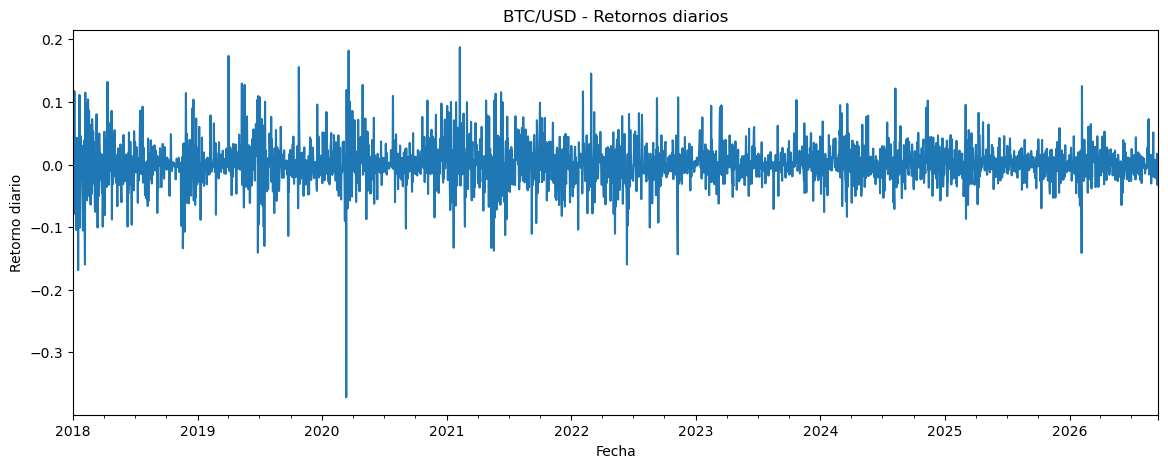

In [13]:
btc["daily_return"].plot(
    figsize=(14, 5),
    title="BTC/USD - Retornos diarios"
)

plt.xlabel("Fecha")
plt.ylabel("Retorno diario")
plt.show()

## 6. Medias móviles

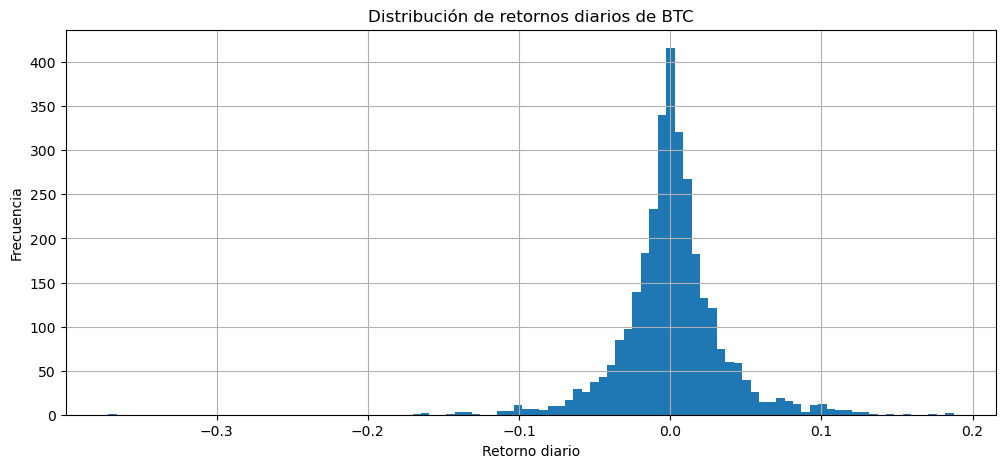

In [15]:
btc["daily_return"].hist(bins=100, figsize=(12, 5))

plt.title("Distribución de retornos diarios de BTC")
plt.xlabel("Retorno diario")
plt.ylabel("Frecuencia")
plt.show()

In [16]:
skewness = btc["daily_return"].skew()
kurtosis = btc["daily_return"].kurt()

print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

Skewness: -0.2857
Kurtosis: 8.4239


1. Skewness = −0.2857

Una distribución perfectamente simétrica tendría:

$$ Skewness = 0 $$

Vos obtuviste:

$$ -0.2857 $$

El signo negativo indica cierta asimetría hacia la izquierda: la cola negativa es algo más pronunciada. No significa que Bitcoin normalmente baje; significa que la distribución de magnitudes de los retornos no es perfectamente simétrica y presenta algo más de peso hacia retornos negativos extremos.

Esto encaja con algo que ya encontramos:

Mínimo: -37.17%
Máximo: +18.75%

Ese −37 % tiene bastante peso en la distribución.

2. Kurtosis = 8.4239

Este resultado es especialmente importante.

Pandas kurt() reporta excess kurtosis, donde una distribución normal tiene:

$$ Kurtosis = 0 $$

Y nosotros tenemos:

$$ \boxed{8.4239} $$

Es un valor muy elevado.

Eso indica que la distribución histórica de retornos de nuestro dataset presenta colas pesadas y muchos más valores extremos de lo que esperaríamos bajo una distribución normal.

Y tu gráfico lo hace bastante visible. La mayoría de los días está alrededor de cero:

                 │
                 │
        ─────────0─────────
          ↑↑↑↑↑↑↑↑↑↑
       mayoría de días

pero periódicamente aparecen movimientos enormes:

 +20% ┤        │
      │        │
   0% ┼────────┼────────────
      │    │       │
 -20% ┤    │       │
      │    │
 -37% ┤    ▼

En tu gráfico se distingue particularmente esa enorme caída alrededor de 2020.

3. Esto tiene consecuencias para nuestra futura estrategia

Supongamos que más adelante nuestra estrategia genera buenos retornos promedio. No podremos concluir simplemente:

"La estrategia es buena porque gana bastante."

También tendremos que preguntar:

¿Qué riesgo tuvimos que asumir para conseguir ese retorno?

Porque nuestro EDA ya nos está advirtiendo que BTC puede experimentar movimientos extremos.

Por eso posteriormente compararemos:

$$ \text{Return} $$

con cosas como:

$$ \text{Volatility} $$ $$ \text{Sharpe Ratio} $$ $$ \text{Maximum Drawdown} $$

Una estrategia que produzca +50 % con un drawdown de −70 % cuenta una historia muy diferente de otra que produzca +40 % con un drawdown de −20 %.

Aquí vamos a notar una diferencia importante: el gráfico de Close tiene tendencia de largo plazo, pero el de retornos oscila alrededor de 0. Esto será mucho más útil cuando empecemos a analizar riesgo y volatilidad.

Análisis describe
1. El retorno promedio parece pequeño... pero no lo es
equivale aproximadamente a:

$$ 0.0011\times100=0.11\% $$

por día.

Pero cuidado con interpretar esto como:

"Bitcoin genera 0,11 % todos los días".

No. Significa que el promedio histórico de los retornos diarios de nuestra muestra fue 0,11 %.

Hay días de +10 %, −8 %, +2 %, −5 %, etc.

Precisamente ahí entra nuestra siguiente métrica.

2. Volatilidad: 3,32 % diaria

La desviación estándar de los retornos es aproximadamente:

$$ 3.32\% $$

diaria.

Compará:
Retorno medio       +0,11 %
Volatilidad           3,32 %
                      ↑
                 ~30 veces
                 el promedio

Eso ya nos dice algo importante sobre BTC: el ruido diario es enorme comparado con su retorno diario promedio.

Esta relación entre retorno y volatilidad va a aparecer nuevamente cuando calculemos el Sharpe Ratio.

3. Los extremos son muy importantes

Tenemos:

$$ Min=-37.17\% $$

y:

$$ Max=+18.75\% $$

Es decir, dentro de nuestro período hubo al menos un día con una caída extraordinariamente grande.

Esto es exactamente por lo que te pedí que miráramos la distribución de retornos.

Si mirás tu histograma, probablemente tengas una gran concentración alrededor de:
0 %

y unas observaciones bastante alejadas.

Esas son las famosas colas (tails).

Y para trading son importantísimas.

Un modelo que asuma que movimientos extremos son prácticamente imposibles puede subestimar muchísimo el riesgo.

4. Los percentiles nos cuentan cómo es un día más "normal"

Tenemos:

25%     -1,35 %
50%     +0,06 %
75%     +1,49 %

Esto significa que aproximadamente el 50 % central de las observaciones está entre:

$$ -1.35\%\quad\text{y}\quad+1.49\% $$

Eso es mucho más representativo de un día habitual que mirar simplemente:

min = -37 %
max = +19 %

Y además vemos una mediana:

$$ +0.063\% $$

muy cercana a cero.

5. Acá aparece una idea fundamental de Data Science

Tenemos:

mean      +0,110 %
median    +0,063 %

No son iguales.

Y tenemos observaciones extremas.

Eso debería hacernos preguntar:

¿Los retornos diarios de Bitcoin siguen realmente una distribución normal?

No vamos a asumir la respuesta.

La vamos a investigar.

Eso es justamente lo que quiero que tenga este proyecto: pregunta → evidencia → conclusión, en lugar de asumir cosas porque son habituales en trading.

### Medias móviles como análisis de tendencia

Como parte del análisis exploratorio se calculan medias móviles de
20 y 50 períodos para observar el comportamiento de la tendencia
del precio.

En esta etapa las medias móviles se utilizan únicamente con fines
exploratorios. La generación de señales y su utilización dentro de
una estrategia se realizará en el siguiente notebook.

In [25]:
btc["SMA_20"] = btc["Close"].rolling(20).mean()
btc["SMA_50"] = btc["Close"].rolling(50).mean()

Las gráficamos junto a los precios

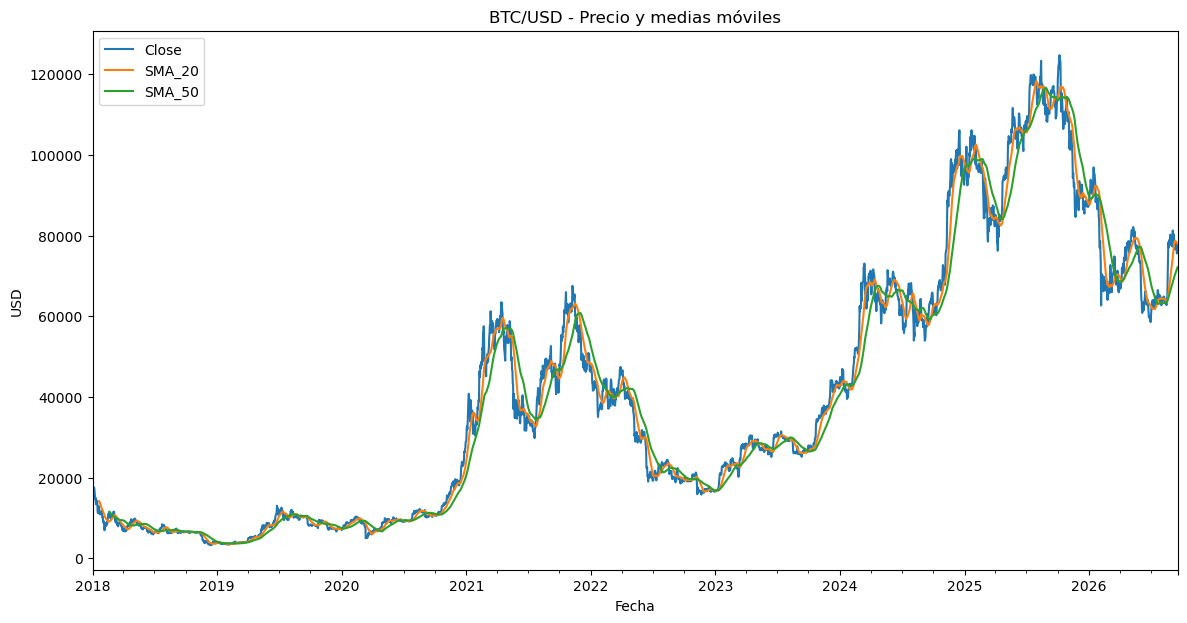

In [27]:
btc[["Close", "SMA_20", "SMA_50"]].plot(figsize=(14, 7))

plt.title("BTC/USD - Precio y medias móviles")
plt.xlabel("Fecha")
plt.ylabel("USD")
plt.show()

## Conclusiones iniciales

Los retornos diarios de Bitcoin presentan una **alta volatilidad** y una distribución que muestra diferencias importantes respecto de una distribución normal.

El retorno diario promedio durante el período analizado es aproximadamente de **0,11%**, mientras que la volatilidad diaria es considerablemente mayor, alcanzando aproximadamente un **3,32%**.

El análisis de la distribución de los retornos muestra:

- **Asimetría (Skewness): -0,2857**, lo que indica una leve asimetría negativa y una mayor presencia relativa de movimientos extremos hacia retornos negativos.
- **Curtosis excedente (Kurtosis): 8,4239**, un valor elevado que indica la presencia de colas pesadas y una frecuencia de retornos extremos considerablemente mayor a la que se esperaría bajo una distribución normal.

Además, durante el período analizado se observaron movimientos diarios extremos, con un retorno mínimo cercano al **-37,17%** y un máximo aproximado del **+18,75%**.

Estos resultados muestran que evaluar una estrategia de trading únicamente a partir de su rentabilidad promedio sería insuficiente. Una estrategia puede generar retornos positivos y, al mismo tiempo, estar expuesta a niveles de riesgo elevados.

Por este motivo, durante la etapa de backtesting será necesario incorporar métricas que permitan evaluar conjuntamente **rentabilidad y riesgo**, entre ellas:

- Volatilidad
- Sharpe Ratio
- Maximum Drawdown
- Rentabilidad acumulada
- Comparación contra Buy & Hold

Este análisis exploratorio establece una primera característica relevante del activo estudiado: **Bitcoin combina retornos históricos positivos con una elevada volatilidad y una presencia significativa de eventos extremos**, aspectos que deberán ser considerados en el diseño y evaluación de la estrategia cuantitativa.